In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
%pip install pandas numpy matplotlib scikit-learn seaborn

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Usin

In [4]:
x = np.array([3, 5, 7, 6, 9]).reshape(5, 1) # расходы на рекламу за 5 месяцев
y = np.array([3, 7, 11, 14, 15]).reshape(5, 1) # объемы продаж

$$y = w_0 +w_1x +\epsilon$$
$$Error = \sum_{i=1}^n{(y_i - w_0 -w_1x_i)^2}$$

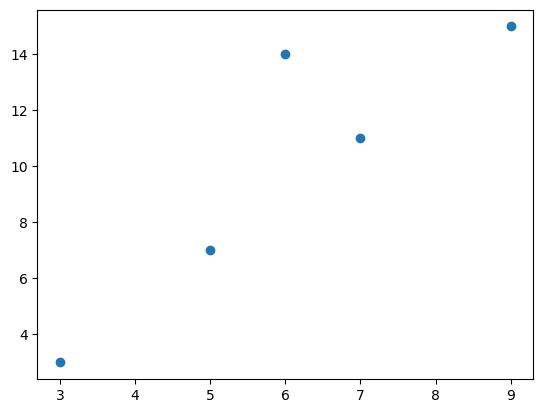

In [3]:
plt.scatter(x, y)

Градиент - вектор, составленных прроизводных функции

Градиент направлен в сторону наискорейшего возрастания функции

Зададим начальные значения коэффициентов модели $w^{(0)} = (w_0, w_1)$

Запустим процесс обучения по шагам. На каждом шаге будем вычислять градиент функции ошибки $\nabla E = \left(\frac {\partial{E}}{\partial{w_0}}, \frac {\partial{E}}{\partial{w_1}}\right)$

И изменять значения коэффициентов модели $w = (w_0, w_1)$, двигаясь в сторону против градиента на некоторый шаг $\alpha$, называемый скоростью обучения:

$$w^{(t+1)} = w^{(t)} - \alpha \nabla {E}$$

In [13]:
class LRegr(object):
  def __init__(self):
    self.w0 = 0
    self.w1 = 0

  def predict(self, x):

    return self.w0 + self.w1 * x

  def error(self, x, y):
    return sum((y - self.predict(x))**2)

  def fit(self, x, y):
    alpha = 0.001
    dE_dw0 = 2*sum(self.predict(x) - y)
    dE_dw1 = 2*sum((self.predict(x) - y) * x)
    self.w0 -= alpha * dE_dw0
    self.w1 -= alpha * dE_dw1



In [14]:
lr1 = LRegr()
lr1.predict(0)

0

In [15]:
lr1.predict(100)

0

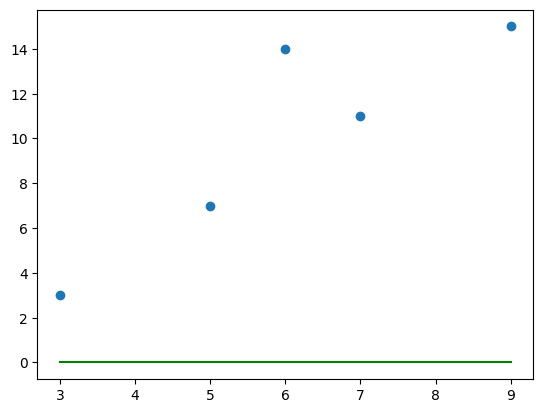

In [16]:
x0 = np.linspace(3, 9, 10)
y0 = lr1.predict(x0)
plt.scatter(x, y)
plt.plot(x0, y0, 'g')

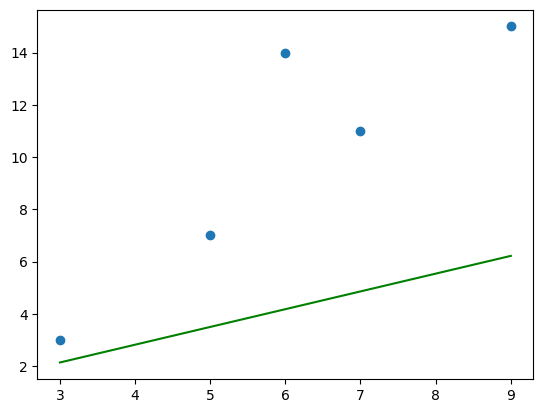

In [17]:
lr1.fit(x, y)
x0 = np.linspace(3, 9, 10)
y0 = lr1.predict(x0)
plt.scatter(x, y)
plt.plot(x0, y0, 'g')

In [18]:
class LRegr(object):
  def __init__(self):
    self.w0 = 0
    self.w1 = 0

  def predict(self, x):

    return self.w0 + self.w1 * x

  def error(self, x, y):
    return sum((y - self.predict(x))**2)

  def fit(self, x, y, alpha = 0.001, n_steps = 1000):
    errors = []
    for _ in range(n_steps):
      dE_dw0 = 2*sum(self.predict(x) - y)
      dE_dw1 = 2*sum((self.predict(x) - y) * x)
      self.w0 -= alpha * dE_dw0
      self.w1 -= alpha * dE_dw1
      errors.append(self.error(x, y))
    return errors

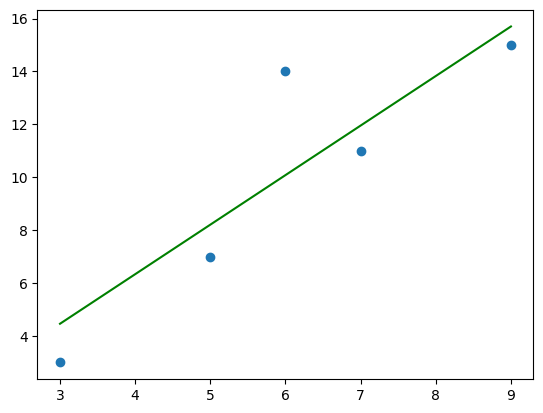

In [19]:
lr1 = LRegr()
errors = lr1.fit(x, y)
x0 = np.linspace(3, 9, 10)
y0 = lr1.predict(x0)
plt.scatter(x, y)
plt.plot(x0, y0, 'g')

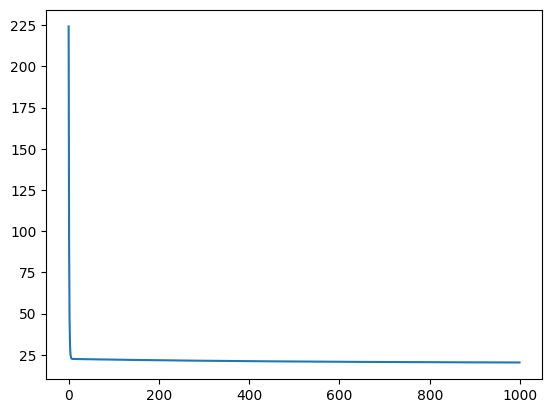

In [20]:
plt.plot(errors)


In [21]:
lr1.w0, lr1.w1

(array([-1.15426628]), array([1.87282903]))

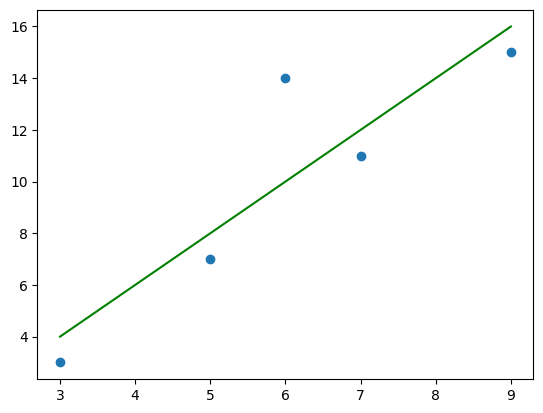

In [22]:
lr1 = LRegr()
errors = lr1.fit(x, y, alpha = 0.001, n_steps = 15000)
x0 = np.linspace(3, 9, 10)
y0 = lr1.predict(x0)
plt.scatter(x, y)
plt.plot(x0, y0, 'g')

In [23]:
lr1.w0, lr1.w1

(array([-1.99999905]), array([1.99999986]))

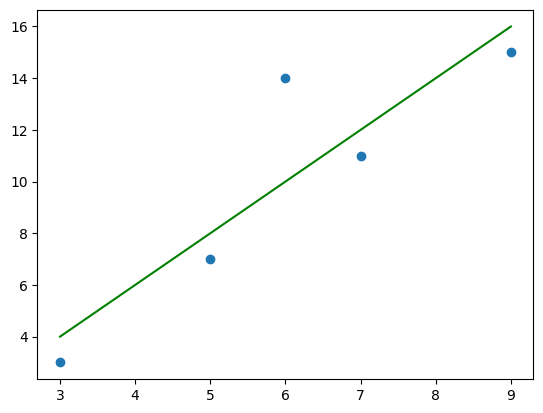

In [24]:
from sklearn.linear_model import LinearRegression
lr2 = LinearRegression()
lr2.fit(x, y)
x0 = np.linspace(3, 9, 10)
y0 = lr1.predict(x0)
plt.scatter(x, y)
plt.plot(x0, y0, 'g')

In [25]:
lr2.intercept_, lr2.coef_

(array([-2.]), array([[2.]]))

In [26]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
print(x_train, x_test)

[[3]
 [6]
 [5]
 [7]] [[9]]


In [27]:
lr2.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
lr2.predict(x_test)

array([[17.85714286]])

In [29]:
y_test

array([[15]])

$$MAE = Mean Absolute Error = \frac{\sum_{i=1}^n{|y_i - w_0 - w_1x_i|}}{n}$$

In [30]:
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(lr2.predict(x_train), y_train))
print(mean_absolute_error(lr2.predict(x_test), y_test))

1.7142857142857146
2.857142857142854


In [5]:
!pip install catboost

  Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached narwhals-2.20.0-py3-none-any.whl.metadata (15 kB)
Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl (100.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.20.0-py3-none-any.whl (449 kB)

   ---------------------------------------- 0/4 [narwhals]
   ---------------------------------------- 0/4 [narwhals]
   ---------- ----------------------------- 1/4 [graphviz]
   -------------------- ------------------- 2/4 [plotly]
   -------------------- ------------------- 2/4 [plotly]
   -------------------- ------------------- 2/4 [plotly]
   -------------------- ------------------- 2/4 [plotly]
   -------------------- ------------------- 2/4 [plotly]
   -------------------- ------------------- 2/

In [31]:
from catboost import CatBoostRegressor
cb = CatBoostRegressor()
cb.fit(x_train, y_train)
print(mean_absolute_error(cb.predict(x_train), y_train))
print(mean_absolute_error(cb.predict(x_test), y_test))

Learning rate set to 0.017112
0:	learn: 4.1248598	total: 104ms	remaining: 1m 43s
1:	learn: 4.1017978	total: 104ms	remaining: 51.9s
2:	learn: 4.0877353	total: 104ms	remaining: 34.7s
3:	learn: 4.0671743	total: 105ms	remaining: 26.1s
4:	learn: 4.0475172	total: 105ms	remaining: 20.9s
5:	learn: 4.0336806	total: 105ms	remaining: 17.4s
6:	learn: 4.0199619	total: 105ms	remaining: 15s
7:	learn: 4.0080843	total: 106ms	remaining: 13.1s
8:	learn: 3.9945756	total: 106ms	remaining: 11.6s
9:	learn: 3.9722014	total: 106ms	remaining: 10.5s
10:	learn: 3.9500083	total: 106ms	remaining: 9.51s
11:	learn: 3.9331102	total: 106ms	remaining: 8.71s
12:	learn: 3.9111912	total: 106ms	remaining: 8.04s
13:	learn: 3.8916627	total: 106ms	remaining: 7.46s
14:	learn: 3.8785425	total: 106ms	remaining: 6.96s
15:	learn: 3.8592198	total: 106ms	remaining: 6.53s
16:	learn: 3.8404778	total: 106ms	remaining: 6.14s
17:	learn: 3.8218615	total: 106ms	remaining: 5.8s
18:	learn: 3.8055116	total: 106ms	remaining: 5.49s
19:	learn: 3.

In [38]:
data = pd.read_csv("Video_Games.csv")
data

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Rapala Trophies,PSP,2006.0,Sports,Activision,0.04,0.00,0.00,0.00,NaN,NaN,NaN,NaN,Sand Grain Studios,E
1,New Super Mario Bros. U,WiiU,2012.0,Platform,Nintendo,2.30,1.34,1.27,0.32,84.0,70.0,8.1,733.0,Nintendo,E
2,Robots,PS2,2005.0,Action,Vivendi Games,0.18,0.14,0.00,0.05,53.0,6.0,6.0,8.0,Eurocom Entertainment Software,E
3,Hamster Club 3,GBA,2002.0,Simulation,Jorudan,0.00,0.00,0.35,0.01,NaN,NaN,NaN,NaN,NaN,NaN
4,Formula 1 06,PS2,2006.0,Racing,Sony Computer Entertainment,0.00,0.00,0.04,0.00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11698,Call of Duty: Black Ops,X360,2010.0,Shooter,Activision,9.70,3.68,0.11,1.13,87.0,89.0,6.3,1454.0,Treyarch,M
11699,Resistance 3,PS3,2011.0,Shooter,Sony Computer Entertainment,0.64,0.57,0.05,0.22,83.0,91.0,7.8,543.0,Insomniac Games,M
11700,Ready 2 Rumble Revolution,Wii,2009.0,Sports,Atari,0.15,0.00,0.00,0.01,37.0,31.0,NaN,NaN,10tacle Studios,T
11701,Monster Hunter Frontier Online: Forward 2,X360,2011.0,Role-Playing,Capcom,0.00,0.00,0.03,0.00,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
y = data.JP_Sales
x = data.drop(columns = ['JP_Sales', 'Name', 'Developer'])
x = x.fillna(0)
x = pd.get_dummies(x, drop_first = True)
x

,Year_of_Release,NA_Sales,EU_Sales,Other_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Platform_3DO,Platform_3DS,...,"Publisher_mixi, Inc",Publisher_responDESIGN,Rating_AO,Rating_E,Rating_E10+,Rating_EC,Rating_K-A,Rating_M,Rating_RP,Rating_T
0,2006.0,0.04,0.00,0.00,0.0,0.0,0.0,0.0,False,False,...,False,False,False,True,False,False,False,False,False,False
1,2012.0,2.30,1.34,0.32,84.0,70.0,8.1,733.0,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2005.0,0.18,0.14,0.05,53.0,6.0,6.0,8.0,False,False,...,False,False,False,True,False,False,False,False,False,False
3,2002.0,0.00,0.00,0.01,0.0,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2006.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11698,2010.0,9.70,3.68,1.13,87.0,89.0,6.3,1454.0,False,False,...,False,False,False,False,False,False,False,True,False,False
11699,2011.0,0.64,0.57,0.22,83.0,91.0,7.8,543.0,False,False,...,False,False,False,False,False,False,False,True,False,False
11700,2009.0,0.15,0.00,0.01,37.0,31.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,False,True
11701,2011.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [40]:
x.shape, y.shape

((11703, 577), (11703,))

In [41]:
x_train.shape, y_train.shape

((4, 1), (4, 1))

In [42]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
lregr = LinearRegression()
lregr.fit(x_train, y_train)
print(mean_absolute_error(lregr.predict(x_train), y_train))
print(mean_absolute_error(lregr.predict(x_test), y_test))

0.08747246378890265
0.10438702307791682


In [43]:
y.mean()

np.float64(0.07912928308980603)

Задача. Улучшить качество. Варианты: использовать полиномы, использовать catboost, перейти к логарифмам и попробовать еще что-то

In [56]:
# Импорт дополнительных модулей для обработки текстовых данных и дат
import warnings
warnings.filterwarnings('ignore') # Подавление системных предупреждений для чистоты отчета


# Первичный осмотр структуры
display(data.head())
print(f"\nОбщая размерность массива данных: {data.shape} строк и {data.shape} столбцов.")


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Rapala Trophies,PSP,2006.0,Sports,Activision,0.04,0.00,0.00,0.00,NaN,NaN,NaN,NaN,Sand Grain Studios,E
1,New Super Mario Bros. U,WiiU,2012.0,Platform,Nintendo,2.30,1.34,1.27,0.32,84.0,70.0,8.1,733.0,Nintendo,E
2,Robots,PS2,2005.0,Action,Vivendi Games,0.18,0.14,0.00,0.05,53.0,6.0,6.0,8.0,Eurocom Entertainment Software,E
3,Hamster Club 3,GBA,2002.0,Simulation,Jorudan,0.00,0.00,0.35,0.01,NaN,NaN,NaN,NaN,NaN,NaN
4,Formula 1 06,PS2,2006.0,Racing,Sony Computer Entertainment,0.00,0.00,0.04,0.00,NaN,NaN,NaN,NaN,NaN,NaN



Общая размерность массива данных: (11703, 15) строк и (11703, 15) столбцов.


Санитарная обработка данных (Data Cleansing)

---


Перед началом статистического агрегирования необходимо устранить артефакты, присутствующие в наборе. Например, в столбце пользовательских оценок (User_Score) часто встречается строковое значение tbd (To Be Determined), указывающее на недостаточное количество голосов для формирования рейтинга. Эта строковая примесь препятствует конвертации всего столбца в формат с плавающей запятой (float). Данный артефакт заменяется на математический эквивалент отсутствия данных (NaN).1
Далее производится удаление записей с пропущенным годом выпуска (Year_of_Release), так как временная ось является критическим базисом для анализа исторических трендов жизненного цикла игровых платформ.1 Если набор данных по какой-либо причине не содержит предварительно вычисленного столбца совокупных глобальных продаж (Global_Sales), он создается синтетически путем построчной суммы всех четырех региональных векторов продаж.2





In [57]:
# 1. Нормализация регистра в наименованиях столбцов для упрощения синтаксиса
data.columns = data.columns.str.lower()

# 2. Очистка и трансформация столбца пользовательских оценок
if 'user_score' in data.columns:
    # Изоляция и замена строковых артефактов 'tbd' на системный NaN
    data['user_score'] = data['user_score'].replace('tbd', np.nan)
    # Форсированная конвертация столбца в тип данных с плавающей запятой
    data['user_score'] = data['user_score'].astype(float)
    print("Трансформация 'user_score' выполнена: артефакты 'tbd' устранены.")

# 3. Фильтрация записей с отсутствующей хронологией
if 'year_of_release' in data.columns:
    initial_shape = data.shape[0]   # только количество строк, а не кортеж
    data = data.dropna(subset=['year_of_release'])
    data['year_of_release'] = data['year_of_release'].astype(int)
    removed = initial_shape - data.shape[0]
    print(f"Записи без даты релиза удалены. Исключено {removed} строк.")

# 4. Агрегирование столбца глобальных продаж
# Суммирование региональных рынков (Северная Америка, Европа, Япония, Остальной мир)
if 'global_sales' not in data.columns:
    data['global_sales'] = data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
    print("Столбец 'global_sales' синтезирован на основе региональных показателей.")


Трансформация 'user_score' выполнена: артефакты 'tbd' устранены.
Записи без даты релиза удалены. Исключено 195 строк.
Столбец 'global_sales' синтезирован на основе региональных показателей.


In [46]:
!pip install seaborn

In [47]:
import seaborn as sns

Анализ глобальных трендов: Распределения и доминирующие жанры

---


Разведочный анализ начинается с исследования распределения глобальных продаж. В индустрии развлечений доходы распределяются по принципу Парето (тяжелый правый хвост): подавляющее большинство продуктов приносит минимальную прибыль, тогда как редкие хиты (например, спортивные симуляторы или проекты вроде Madden NFL) генерируют львиную долю общего капитала.8 Для визуализации этой диспропорции строится гистограмма, ось абсцисс которой принудительно ограничивается значением в 5 миллионов копий, отсекая экстремальные выбросы для сохранения визуальной читаемости.
Следующим этапом является агрегация совокупных продаж в разрезе жанров. Этот шаг позволяет бизнесу понять, какие категории продуктов наиболее востребованы на глобальном рынке.


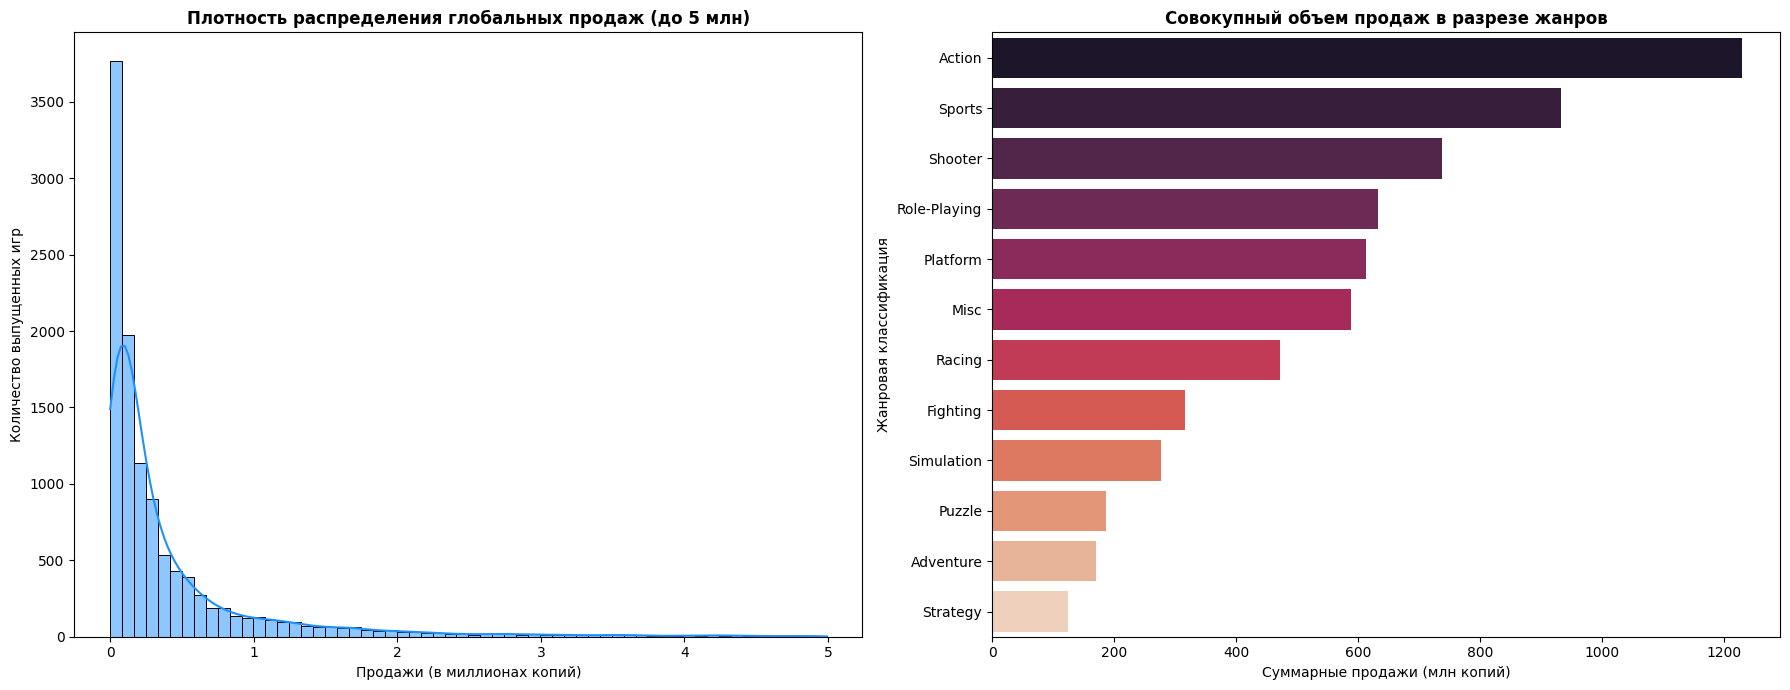

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Визуализация 1: Гистограмма
sns.histplot(
    data[data['global_sales'] <= 5]['global_sales'],
    bins=60, kde=True, ax=axes[0], color='dodgerblue'
)
axes[0].set_title('Плотность распределения глобальных продаж (до 5 млн)', fontweight='bold')
axes[0].set_xlabel('Продажи (в миллионах копий)')
axes[0].set_ylabel('Количество выпущенных игр')

# Визуализация 2: Барплот по жанрам
genre_sales = data.groupby('genre')['global_sales'].sum().reset_index()
genre_sales = genre_sales.sort_values(by='global_sales', ascending=False)

sns.barplot(
    x='global_sales', y='genre', data=genre_sales, ax=axes[1], palette='rocket'
)
axes[1].set_title('Совокупный объем продаж в разрезе жанров', fontweight='bold')
axes[1].set_xlabel('Суммарные продажи (млн копий)')
axes[1].set_ylabel('Жанровая классификация')

plt.tight_layout()
plt.show()

Векторный анализ региональных рынков

---


Дальнейшее исследование направлено на изучение кросс-культурных различий в потребительском поведении. Рынки Северной Америки (NA), Европы (EU) и Японии (JP) исторически демонстрируют существенные отличия в предпочтениях. Как подтверждает анализ, японский рынок имеет выраженный перекос в сторону ролевых игр (Role-Playing) и симуляторов (например, японский хит Hamster Club 3), в то время как американская и европейская аудитории предпочитают жанры Action и Shooter.
Для построения мультивариативного графика (сгруппированной столбчатой диаграммы), широкая структура таблицы pandas (wide format) преобразуется в длинный формат (long format) с использованием функции pd.melt(). Это позволяет библиотеке Seaborn элегантно разделить столбцы по категориям регионов.


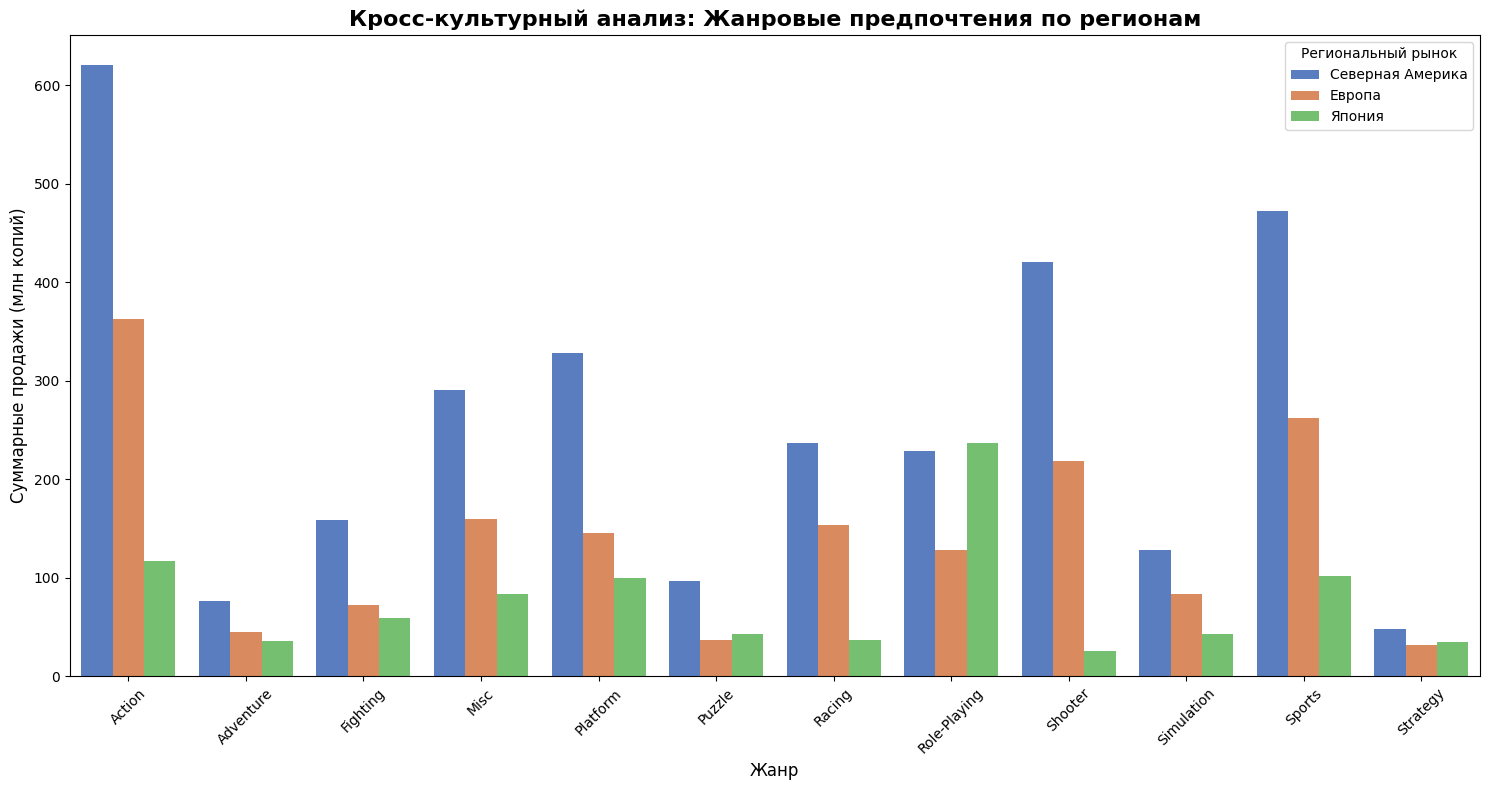

In [59]:
# Агрегирование данных по жанрам и целевым региональным рынкам
regional_genres = data.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum().reset_index()

# Трансформация DataFrame из формата Wide в формат Long для мульти-категориальной визуализации
regional_melted = pd.melt(
    regional_genres,
    id_vars=['genre'],
    value_vars=['na_sales', 'eu_sales', 'jp_sales'],
    var_name='region',
    value_name='sales'
)

# Переименование меток регионов для эстетики графика
regional_melted['region'] = regional_melted['region'].map({
    'na_sales': 'Северная Америка',
    'eu_sales': 'Европа',
    'jp_sales': 'Япония'
})

plt.figure(figsize=(15, 8))
sns.barplot(x='genre', y='sales', hue='region', data=regional_melted, palette='muted')
plt.title('Кросс-культурный анализ: Жанровые предпочтения по регионам', fontsize=16, fontweight='bold')
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Суммарные продажи (млн копий)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Региональный рынок')
plt.tight_layout()
plt.show()


Корреляционный анализ: Влияние профессиональной критики на коммерческий успех

---


В финальной части разведочного анализа проверяется гипотеза о том, что высокие оценки профессиональных профильных критиков прямо коррелируют с финансовым успехом видеоигры. Для оценки силы и направления линейной связи вычисляется коэффициент корреляции Пирсона между переменными critic_score и global_sales.
Кроме того, строится диаграмма рассеяния (scatter plot) с наложенной линией линейной регрессии. Из-за наличия масштабных выбросов (таких хитов, как New Super Mario Bros. U, продающихся тиражами в миллионы копий), ось Y на графике искусственно ограничивается. Результаты показывают, что хотя абсолютной детерминированности нет (высокая оценка не гарантирует статус бестселлера), проекты с низкими оценками практически никогда не достигают вершин коммерческого успеха.


Статистика: Коэффициент корреляции Пирсона (Critic Score vs Global Sales) = 0.232


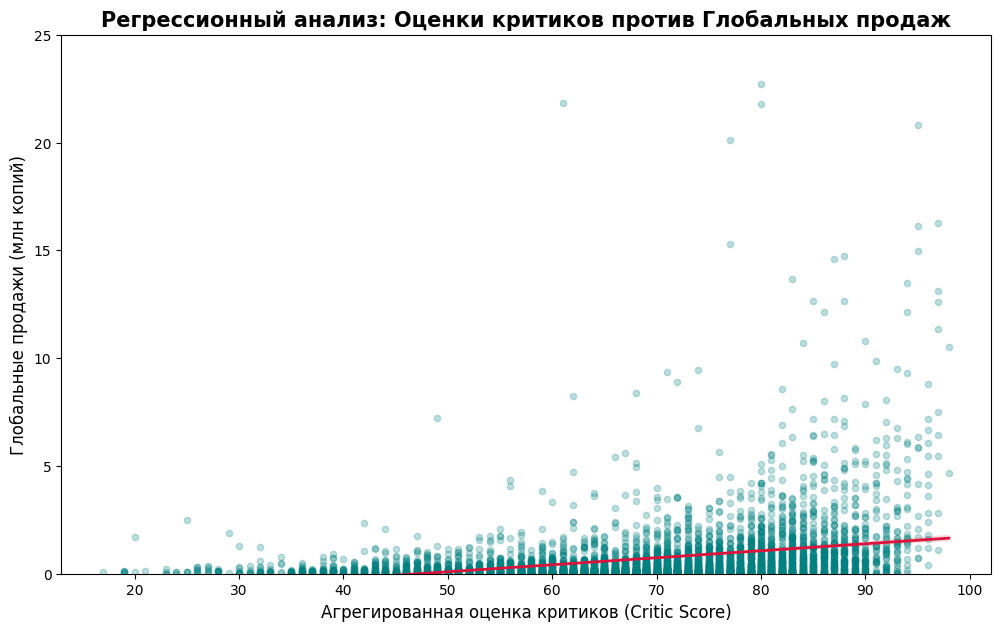

In [60]:
# Подготовка данных: изоляция строк, содержащих валидные оценки критиков
df_scores = data.dropna(subset=['critic_score', 'global_sales']).copy()

# Вычисление коэффициента корреляции Пирсона
correlation_coefficient = df_scores['critic_score'].corr(df_scores['global_sales'])
print(f"Статистика: Коэффициент корреляции Пирсона (Critic Score vs Global Sales) = {correlation_coefficient:.3f}")

# Визуализация диаграммы рассеяния с регрессионным трендом
plt.figure(figsize=(12, 7))
sns.regplot(
    x='critic_score',
    y='global_sales',
    data=df_scores,
    scatter_kws={'alpha': 0.25, 'color': 'teal', 's': 20},
    line_kws={'color': 'crimson', 'linewidth': 2}
)
plt.title('Регрессионный анализ: Оценки критиков против Глобальных продаж', fontsize=15, fontweight='bold')
plt.xlabel('Агрегированная оценка критиков (Critic Score)', fontsize=12)
plt.ylabel('Глобальные продажи (млн копий)', fontsize=12)

# Ограничение оси Y до 25 миллионов для фокусировки на основном кластере данных
plt.ylim(0, 25)
plt.show()


Так как график продаж показал длинный правый хвост, линейным моделям тяжело с ним работать. Обучим базовую модель на логарифме целевой переменной.

In [61]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Логарифмируем таргет (используем log1p, чтобы избежать ошибки log(0))
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Обучаем базовую модель Ridge на логарифмах
ridge_log = Ridge(alpha=1.0)
ridge_log.fit(x_train, y_train_log)

# Делаем предсказание и возвращаем его в обычные числа через экспоненту (expm1)
preds_log = ridge_log.predict(x_test)
preds_exp = np.expm1(preds_log)

print("R2 модели с логарифмированием таргета:", r2_score(y_test, preds_exp))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_exp)))


R2 модели с логарифмированием таргета: 0.42371194090652053
RMSE: 0.2762829683233902


Теперь добавим полиномиальные признаки, чтобы модель могла улавливать взаимодействия между факторами.

In [62]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Создаем пайплайн: сначала генерируем полиномы, затем применяем регрессию
# Увеличиваем alpha, так как количество признаков резко возрастет
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=10.0)
)

poly_model.fit(x_train, y_train_log)

preds_poly_log = poly_model.predict(x_test)
preds_poly = np.expm1(preds_poly_log)

print("R2 модели с полиномами:", r2_score(y_test, preds_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_poly)))


R2 модели с полиномами: -5.648937446302251
RMSE: 0.9384484609458121


Линейные модели с трудом улавливают сложную структуру табличных данных. Применим градиентный бустинг от Яндекса — CatBoost.

In [63]:
# Инициализируем модель градиентного бустинга
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=0 # Отключаем лишний вывод текста при обучении
)

# Обучаем CatBoost на логарифмированном таргете (это все еще важно!)
cb_model.fit(x_train, y_train_log, eval_set=(x_test, y_test_log), early_stopping_rounds=50)

# Предсказываем и возвращаем масштаб
cb_preds_log = cb_model.predict(x_test)
cb_preds = np.expm1(cb_preds_log)

print("R2 модели CatBoost:", r2_score(y_test, cb_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, cb_preds)))


R2 модели CatBoost: 0.49260925966972335
RMSE: 0.25924212428175325


Помня о графиках распределения, где мы видели огромные хвосты, попробуем очистить тренировочные данные от аномальных суперхитов (выбросов), которые сбивают алгоритм. Также посмотрим, какие признаки CatBoost считает самыми важными.

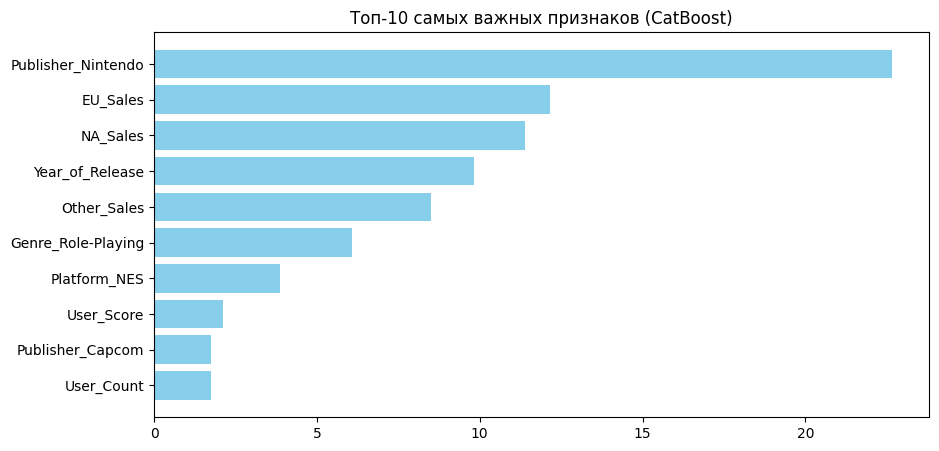

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Анализ важности признаков ---
feature_importance = cb_model.get_feature_importance()
features = x_train.columns if isinstance(x_train, pd.DataFrame) else [f'Feature_{i}' for i in range(x_train.shape[1])]

df_imp = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(df_imp['Feature'][:10], df_imp['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Топ-10 самых важных признаков (CatBoost)')
plt.show()

In [65]:
# --- 2. Фильтрация супер-выбросов ---
# Предположим, что игры с продажами > 15 млн копий - это уникальные выбросы (Wii Sports и т.д.)
# Они мешают предсказывать продажи обычных игр. Уберем их только из TRAIN выборки.

# Находим индексы нормальных значений
mask = y_train < 15.0

# Фильтруем данные
X_train_filtered = x_train[mask] if isinstance(x_train, pd.DataFrame) else x_train[mask]
y_train_filtered_log = y_train_log[mask]

# Переобучаем CatBoost на очищенных данных
cb_model_clean = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=0, random_seed=42)
cb_model_clean.fit(X_train_filtered, y_train_filtered_log)

clean_preds = np.expm1(cb_model_clean.predict(x_test))

print("R2 CatBoost (после удаления выбросов из Train):", r2_score(y_test, clean_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, clean_preds)))


R2 CatBoost (после удаления выбросов из Train): 0.49260925966972335
RMSE: 0.25924212428175325


Во втором разделе, посвященном датасету Video_Games.csv, методы разведочного анализа (EDA) были применены для вскрытия структурных закономерностей рынка интерактивных развлечений. Агрегация данных неоспоримо доказала доминирование жанров Action и Sports в мировом масштабе. Однако детальный кросс-культурный анализ (Melt-трансформация) выявил критическую региональную сегментацию: потребительское поведение японского рынка кардинально отличается от западного, фокусируясь на жанре Role-Playing. Финальный регрессионный анализ выявил умеренную положительную корреляцию между профессиональной оценкой продукта и его продажами, подтвердив гипотезу о том, что институциональное признание критиками задает минимальную планку качества, необходимую для коммерческого триумфа продукта, хотя и не является единственным его драйвером.
